# Module 2: Data Preprocessing and Feature Engineering  
This notebook transforms raw data into **predictive features**.  
The main focus is on applying **Cross-Sectional Ranking** to normalize data across different stocks at the same point in time.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sklearn
import time
import os
import sys
import seaborn as sns

project_root = os.path.abspath("../../")

if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.evaluation as ev
import src.models as md 


d:\AI\Stock Analysis\trading_system\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

FILE_URL = "../../data/market_data.parquet"
df = pd.read_parquet(FILE_URL)
df = df[df["close"] > 0]
df.head()

,date,open,high,low,close,volume,Symbol
0,2017-08-08,4.63,4.65,4.55,4.56,382940,ACB
1,2017-08-09,4.56,4.56,4.46,4.49,1649412,ACB
2,2017-08-10,4.46,4.51,4.44,4.46,1139760,ACB
3,2017-08-11,4.48,4.48,4.44,4.46,774623,ACB
4,2017-08-14,4.44,4.51,4.44,4.51,657975,ACB


## 2.1 Feature Selection Rationale
In this project, I select 8 primary features categorized into three groups to capture the Vietnamese stock market's dynamics:

* **Momentum Indicators**: `log_ret_1m`, `log_ret_3m`, `log_ret_1y` - These capture the trend-following behavior of investors.
* **Risk & Volatility**: `volatility_3m`, `volatility_shock_monthly` - These measure the systematic and unsystematic risk levels.
* **Trend & Liquidity**: `dist_SMA_100`, `RSI_14`, `volume_surge_monthly` - These identify overbought/oversold conditions and abnormal trading interest.

### Cross-Sectional Ranking
Instead of using absolute values, I apply **Cross-Sectional Ranking** to every feature. This technique normalizes data across 100 tickers at each timestamp, effectively removing "Market Beta" and focusing on the relative strength (Alpha) of each stock within the VN100 basket.

In [3]:
# Define your features and target
features = [
    'log_ret_1m', 'log_ret_3m', 'log_ret_1y',
    'volatility_shock_monthly', 'volatility_3m',
    'dist_SMA_100', 'RSI_14', 'volume_surge_monthly'
]

In [4]:
df = ft.build_features(df)
df = ft.target_generating_ranking(df)
#df,new_features = ft.apply_cross_sectional_ranking(df,features)
#features = features + new_features

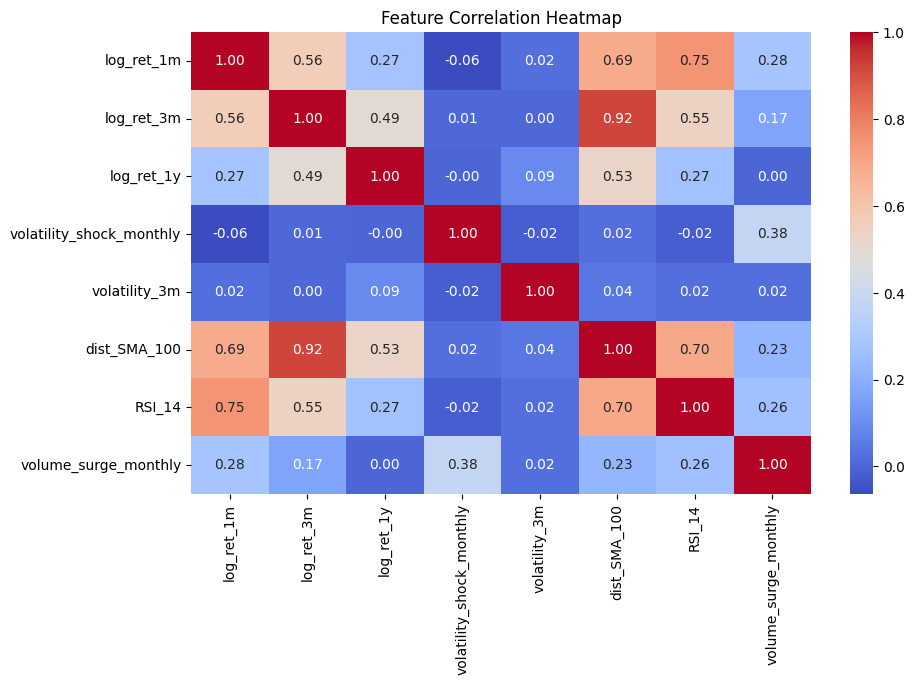

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()